# AquaTrack

## STEP 0: PROJECT HEADER
- **Purpose:** engineer `dehydration_level` target via KMeans + ordered mapping.
- **Dataset:** `dehydration_estimation.csv`.
- **Module:** Main.
- **Inputs:** prepared numeric feature subset.
- **Outputs:** labeled dataset and clustering diagnostics.

## STEP 1: TARGET ENGINEERING
- Derive ordered dehydration classes from clustering signals.
- **Inputs:** model-ready numeric features.
- **Outputs:** `dehydration_level` labels and diagnostics.

**Primary biomarkers only** (6 sweat/saliva features) → median impute → **RobustScaler** → **KMeans(k=3)**.

Categorical **`dehydration_level`** ∈ {Low, Medium, High} comes from **cluster ordering** using a **dehydration level metric**: sum of **z-scores** of cluster centroids vs the global imputed distribution (no fixed clinical thresholds).

Exports **`aquatrack_labeled.csv`** with all original columns + `dehydration_level`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "models").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Legacy package imports removed.
# Inline functions/constants should be used in this notebook.

plt.rcParams["figure.figsize"] = (10, 4)
df = load_prepared()
print("Rows:", len(df), "| Primary clustering features:", len(PRIMARY_FEATURES))

NameError: name 'load_prepared' is not defined

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 10
CLUSTER_K = 3

# === STEPS 1–6: fit + export ===
Elbow/silhouette diagnostics, **k=3** enforced, optional imbalance refit (silhouette comparison only).

In [ ]:
out, metrics = run_pipeline(df, export_path=config.LABELED_CSV, refit_if_imbalanced=True)
tc = config.TARGET_COL
print("Export:", len(out), "rows |", out[tc].value_counts().to_dict())

Export: 90 rows | {'Low': 69, 'Medium': 16, 'High': 5}


# === STEP 2: elbow + silhouette ===

Best k (silhouette): 2 | Fixed k: 3
 k    inertia  silhouette
 2 481.063571    0.464119
 3 365.713138    0.442834
 4 287.942464    0.401419
 5 248.046152    0.235959
 6 220.701376    0.234304


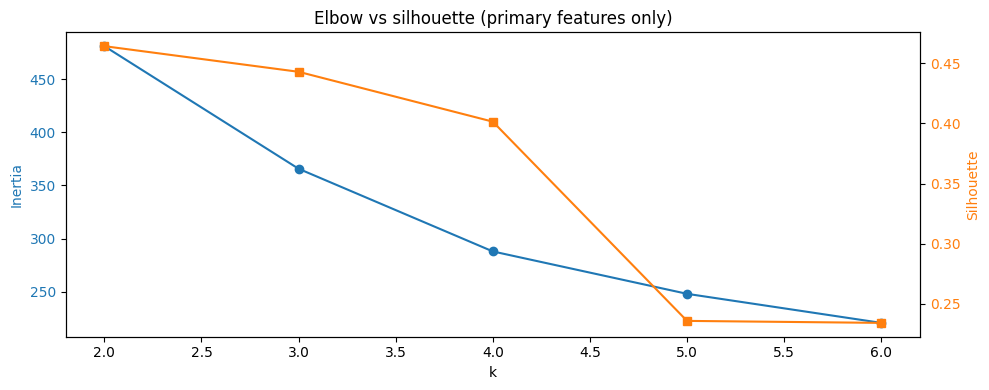

In [ ]:
curve = metrics["elbow_silhouette_curve"]
print("Best k (silhouette):", metrics["best_silhouette_k"], "| Fixed k:", metrics["k_used"])
print(curve.to_string(index=False))
fig, ax1 = plt.subplots()
ax1.plot(curve["k"], curve["inertia"], "o-", color="C0")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(curve["k"], curve["silhouette"], "s-", color="C1")
ax2.set_ylabel("Silhouette", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
plt.title("Elbow vs silhouette (primary features only)")
plt.tight_layout()
plt.show()

# === STEP 3–4: cluster → dehydration_level (categorical) ===

In [ ]:
print("Cluster → dehydration_level:", metrics["cluster_to_dehydration_level_map"])
print("\nMetric (z-sum) by cluster:")
print(metrics["dehydration_level_metric_by_cluster"])

Cluster → dehydration_level: {0: 'Low', 1: 'Medium', 2: 'High'}

Metric (z-sum) by cluster:
cluster
0    -1.654074
1     3.605819
2    11.287604
dtype: float64


# === STEP 5: validate ===

Counts:
 dehydration_level
Low       69
Medium    16
High       5
Name: count, dtype: int64
Fractions:
 dehydration_level
Low       0.767
Medium    0.178
High      0.056
Name: count, dtype: float64
Silhouette (k=3): 0.4428
Silhouette after refit (diagnostic): 0.5008

Mean numerics by dehydration_level (first 8 cols):
                   age [years]  height [cm]  running speed [km/h]  \
dehydration_level                                                   
High                       NaN          NaN                   NaN   
Low                       25.5        179.9                  8.72   
Medium                     NaN          NaN                   NaN   

                   running interval  \
dehydration_level                     
High                         7.0000   
Low                          3.3913   
Medium                       5.6875   

                   weight measured using Kern DE 150K2D [kg]  \
dehydration_level                                              
High       

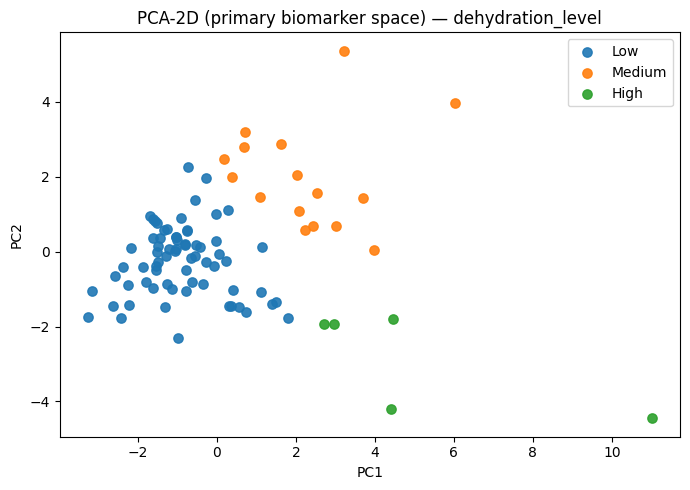

In [ ]:
vc = out[tc].value_counts()
print("Counts:\n", vc)
print("Fractions:\n", (vc / vc.sum()).round(3))
print("Silhouette (k=3):", round(metrics["silhouette_k3"], 4))
if metrics.get("silhouette_k3_after_refit") is not None:
    print("Silhouette after refit (diagnostic):", round(metrics["silhouette_k3_after_refit"], 4))

means = mean_by_dehydration_level(out.drop(columns=[config.COL_ID], errors="ignore"))
print("\nMean numerics by dehydration_level (first 8 cols):")
print(means.iloc[:, :8].round(4))

if (vc / vc.sum()).min() < 0.2:
    print("\n⚠ Smallest class share < 20% — consider subject-level CV or semi-supervised review.")

Xp = metrics["pca_X"]
fig, ax = plt.subplots(figsize=(7, 5))
for lab, c in zip(["Low", "Medium", "High"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    m = out[tc].astype(str) == lab
    ax.scatter(Xp[m, 0], Xp[m, 1], label=lab, alpha=0.9, s=45)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA-2D (primary biomarker space) — dehydration_level")
ax.legend()
plt.tight_layout()
plt.show()

# === STEP 6: export ===

In [ ]:
assert "cluster" not in out.columns
print("Done. Label distribution:")
print(out[tc].value_counts())
print("Saved:", metrics.get("export_path"))

Done. Label distribution:
dehydration_level
Low       69
Medium    16
High       5
Name: count, dtype: int64
Saved: /Users/divyabelumana/Desktop/AquaTrack/aquatrack_labeled.csv
